![Imgur](https://i.imgur.com/5pXzCIu.png)

# Data Science va Sun'iy Intellekt Praktikum

## 5-MODUL. Machine Learning.

### Amaliyot. Simple Linear Regression

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [19]:
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/reklama_sales.csv')
df.head(20)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,15.6


In [21]:
df.shape

(200, 4)

Yuqoridagi jadvalda MohirDev MChJ tomonidan turli OAV larda (`TV`, `Radio`, `Newspaper`) berilgan reklamalar soni va mos keluvchi savdolar (`Sales`) berilgan.

Sizning vazifangiz:
1. Aynan qaysi turdagi OAVda reklama berish savdo o'sishiga ta'sir qiladi aniqlash
2. Topilgan bog'liqlik asosida Simple Linear Regression algorithmi yordamida bashorat modelini qurish.

Ushbu amaliyotda sizning vazifangiz berilgan dataset yordamida Simple Linear Regression model yaratish:
- CRISP-DM metodologiyasiga amal qiling!
- Simple linear regression qo'llash uchun 1 ta ustunni tanlab oling.

In [45]:
# 1 vazifa correlyatsiyaga qarab tasir doirasini aniqlashtirib olamiz
print(df.corr())

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000


In [46]:
# TV va Sales korelyatsiya savdoga tasiri yuqori sababli bularni model ko'rinishiga keltirib train va test setlar qilamiz
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df['TV'].to_numpy()
y = df['Sales'].to_numpy()

In [47]:
#Grafik yondashuv corr
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

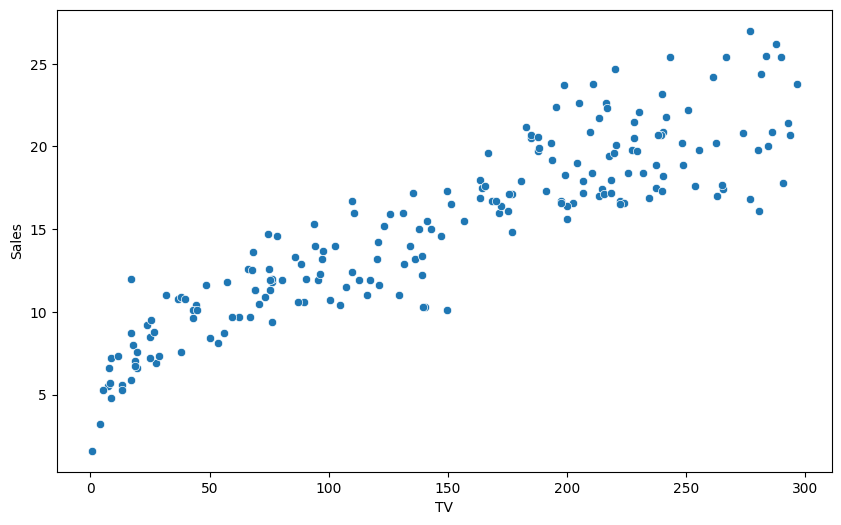

In [24]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='TV', y='Sales')
plt.show()

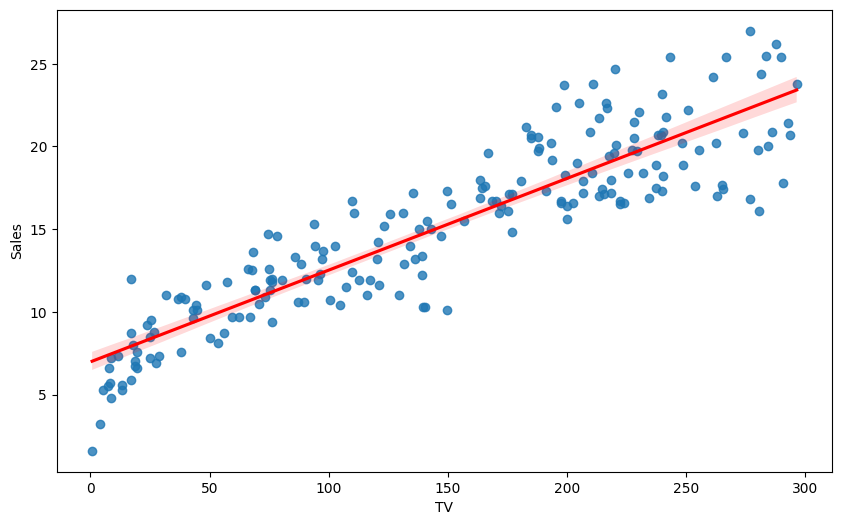

In [25]:
#Chiziq tortib bogliqligini ko'rib olamiz
plt.figure(figsize=(10,6))
sns.regplot(data=df, x='TV', y='Sales', line_kws={"color": "red"})
plt.show()

In [26]:
# TV va Sales ustunlarini numpy ga o'tgazib olib o''rtacha qiymatlarini topib olamiz.
import numpy as np

Xmean = np.mean(X)
ymean = np.mean(y)

In [27]:
#Theta1 va theta0 qiymatlarni topib olamiz
theta1 = sum((X-Xmean)*(y-ymean))/sum((X-Xmean)**2)
print(f"{theta1=}")

theta1=np.float64(0.05546477046955879)


In [28]:
theta0 = ymean - theta1*Xmean
print(f"{theta0=}")

theta0=np.float64(6.974821488229903)


In [31]:
#x_test va y_test uchun malumotlarni chop qilib olamiz
x_test = df.sample(10, random_state=42)['TV'].to_numpy()
print(f"{x_test=}")
y_test = df.sample(10, random_state=42)['Sales'].to_numpy()
print(f"{y_test=}")

x_test=array([163.3, 195.4, 292.9,  11.7, 220.3,  75.1, 216.8,  50. , 222.4,
       175.1])
y_test=array([16.9, 22.4, 21.4,  7.3, 24.7, 12.6, 22.3,  8.4, 16.5, 16.1])


In [32]:
#y_predict (bashorat) tahlili umumiy formulasini yozib olamiz
y_predict = theta0 + theta1*x_test
print(f"{y_predict=}")

y_predict=array([16.03221851, 17.81263764, 23.22045276,  7.6237593 , 19.19371042,
       11.14022575, 18.99958373,  9.74806001, 19.31018644, 16.6867028 ])


In [33]:
MAE = np.sum(np.absolute(y_predict-y_test))/len(y_test)
print(f"{MAE=}")

MAE=np.float64(2.261078526821641)


In [34]:
RMSE = np.sqrt(np.sum((y_predict-y_test)**2)/len(y_test))
print(f"{RMSE=}")

RMSE=np.float64(2.8038786286907422)


In [36]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.10, random_state=42)

In [38]:
#ML_Simple_linear_regression qism orqali malumotlarni chop qilib oldik
from sklearn import linear_model
LR_model = linear_model.LinearRegression()

x_train = np.asanyarray(train_set[['TV']])
y_train = np.asanyarray(train_set[['Sales']])

# Modelni tarbiyalaymiz (train)
LR_model.fit(x_train, y_train)

#theta1 va theta0 koeefisentlarni ajratib olamiz
theta1 = LR_model.coef_[0][0]
theta0 = LR_model.intercept_[0]
print (f'{theta1=}')
print (f'{theta0=}')

theta1=np.float64(0.05513263076693964)
theta0=np.float64(7.044916461655207)


Text(0, 0.5, 'Sales')

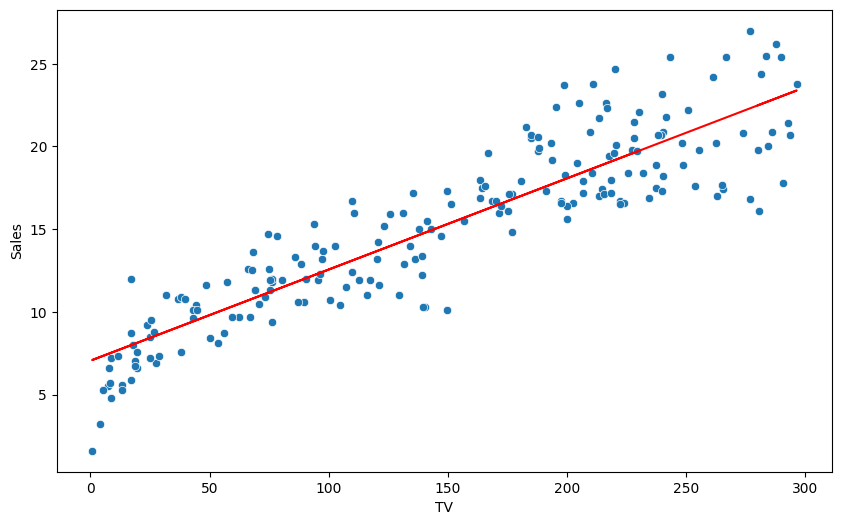

In [40]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='TV', y='Sales')
plt.plot(x_train, theta1*x_train + theta0, '-r')
plt.xlabel("TV")
plt.ylabel("Sales")

In [42]:
# modelni baholaymiz
x_test = np.asanyarray(test_set[['TV']])
y_test = np.asanyarray(test_set[['Sales']])

In [43]:
y_predict = LR_model.predict(x_test)

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

MAE = mean_absolute_error(y_test, y_predict)
RMSE = np.sqrt(mean_squared_error(y_test, y_predict))
print(f"{MAE=}")
print(f"{RMSE=}")

MAE=2.037955356968121
RMSE=np.float64(2.5103822386472214)
